In [1]:
import pandas as pd 
data= pd.read_csv(r'online_retail.csv')

In [2]:
#data.info()
data.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
541904    False
541905    False
541906    False
541907    False
541908    False
Length: 541909, dtype: bool

In [3]:
data=data.drop_duplicates()


In [39]:
data.info() 

<class 'pandas.core.frame.DataFrame'>
Index: 536641 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    536641 non-null  object 
 1   StockCode    536641 non-null  object 
 2   Description  535187 non-null  object 
 3   Quantity     536641 non-null  int64  
 4   InvoiceDate  536641 non-null  object 
 5   UnitPrice    536641 non-null  float64
 6   CustomerID   401604 non-null  float64
 7   Country      536641 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 36.8+ MB


In [4]:
# Remove rows with missing CustomerID
data = data.dropna(subset=['CustomerID'])
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    401604 non-null  object 
 1   StockCode    401604 non-null  object 
 2   Description  401604 non-null  object 
 3   Quantity     401604 non-null  int64  
 4   InvoiceDate  401604 non-null  object 
 5   UnitPrice    401604 non-null  float64
 6   CustomerID   401604 non-null  float64
 7   Country      401604 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.6+ MB


In [5]:
# Exclude cancelled invoices (InvoiceNo starting with 'C')
data = data[~data['InvoiceNo'].astype(str).str.startswith('C')]
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392732 non-null  object 
 1   StockCode    392732 non-null  object 
 2   Description  392732 non-null  object 
 3   Quantity     392732 non-null  int64  
 4   InvoiceDate  392732 non-null  object 
 5   UnitPrice    392732 non-null  float64
 6   CustomerID   392732 non-null  float64
 7   Country      392732 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.0+ MB


In [6]:
# Remove negative or zero quantities and prices
data = data[(data['Quantity'] > 0) & (data['UnitPrice'] > 0)]
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392692 non-null  object 
 1   StockCode    392692 non-null  object 
 2   Description  392692 non-null  object 
 3   Quantity     392692 non-null  int64  
 4   InvoiceDate  392692 non-null  object 
 5   UnitPrice    392692 non-null  float64
 6   CustomerID   392692 non-null  float64
 7   Country      392692 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.0+ MB


In [43]:
display(data['Quantity'].skew())
display(data['UnitPrice'].skew())
display(data['Quantity'].describe())
display(data['UnitPrice'].describe())

np.float64(407.3456626876271)

np.float64(202.7408610735872)

count    392692.000000
mean         13.119702
std         180.492832
min           1.000000
25%           2.000000
50%           6.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

count    392692.000000
mean          3.125914
std          22.241836
min           0.001000
25%           1.250000
50%           1.950000
75%           3.750000
max        8142.750000
Name: UnitPrice, dtype: float64

In [7]:
# Remove outliers in Quantity and UnitPrice using IQR
Q1 = data[['Quantity', 'UnitPrice']].quantile(0.25)
Q3 = data[['Quantity', 'UnitPrice']].quantile(0.75)
IQR = Q3 - Q1

# Keep only rows within 1.5*IQR of Q1 and Q3
data = data[
    ((data['Quantity'] >= (Q1['Quantity'] - 1.5 * IQR['Quantity'])) & 
     (data['Quantity'] <= (Q3['Quantity'] + 1.5 * IQR['Quantity']))) &
    ((data['UnitPrice'] >= (Q1['UnitPrice'] - 1.5 * IQR['UnitPrice'])) & 
     (data['UnitPrice'] <= (Q3['UnitPrice'] + 1.5 * IQR['UnitPrice'])))
]

In [45]:
display(data['Quantity'].skew())
display(data['UnitPrice'].skew())
display(data['Quantity'].describe())
display(data['UnitPrice'].describe())

np.float64(1.1918383454203898)

np.float64(1.0867013205327125)

count    333234.000000
mean          7.550682
std           6.777237
min           1.000000
25%           2.000000
50%           6.000000
75%          12.000000
max          27.000000
Name: Quantity, dtype: float64

count    333234.000000
mean          2.194218
std           1.546015
min           0.001000
25%           1.250000
50%           1.650000
75%           2.950000
max           7.500000
Name: UnitPrice, dtype: float64

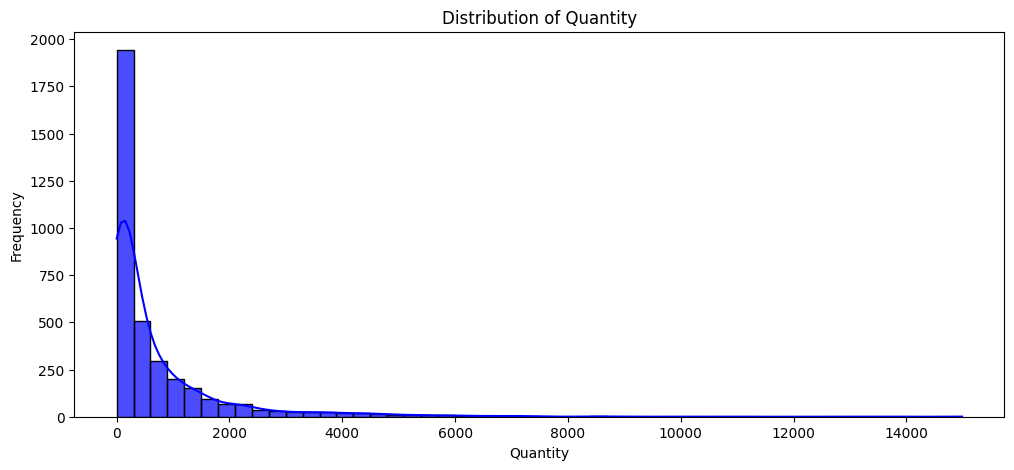

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 5))
sns.histplot(data.groupby('Description')['Quantity'].sum(), bins=50, color='blue', alpha=0.7,kde=True)
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.title('Distribution of Quantity')
plt.show()       

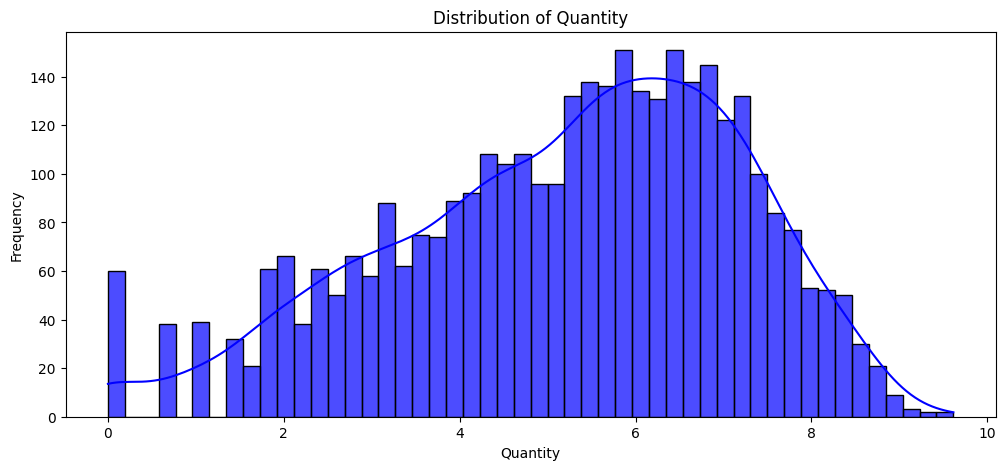

np.float64(1.304844771371681)

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
plt.figure(figsize=(12, 5))
sns.histplot(np.log(data.groupby('Description')['Quantity'].sum()), bins=50, color='blue', alpha=0.7,kde=True)
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.title('Distribution of Quantity')
plt.show()
display(np.log(data.groupby('Description')['Quantity'].sum().skew()) )      



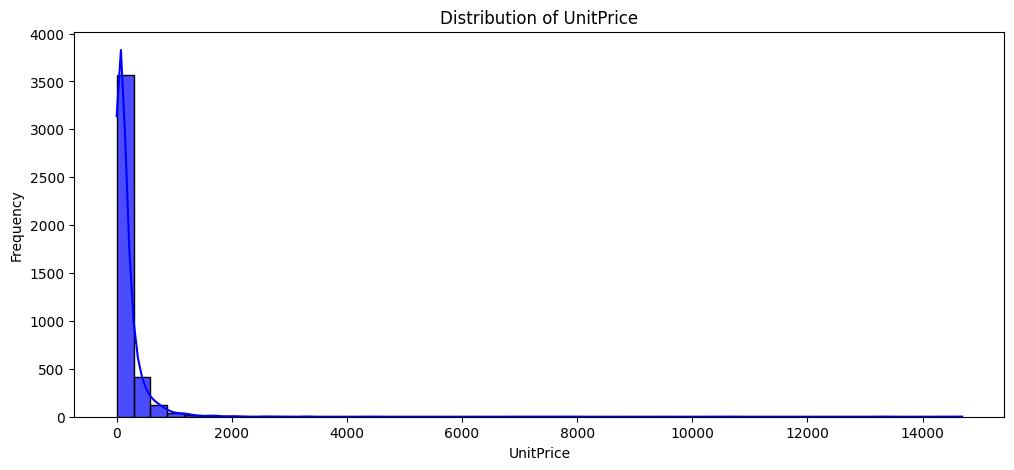

np.float64(19.615337978708215)

np.float64(14687.24)

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 5))
sns.histplot(data.groupby('CustomerID')['UnitPrice'].sum(), bins=50, color='blue', alpha=0.7,kde=True)
plt.xlabel('UnitPrice')
plt.ylabel('Frequency')
plt.title('Distribution of UnitPrice')
plt.show()
display((data.groupby('CustomerID')['UnitPrice'].sum().skew()) )  
display((data.groupby('CustomerID')['UnitPrice'].sum().max()) )  

<Axes: title={'center': 'Transaction Volume by Country'}, xlabel='Country'>

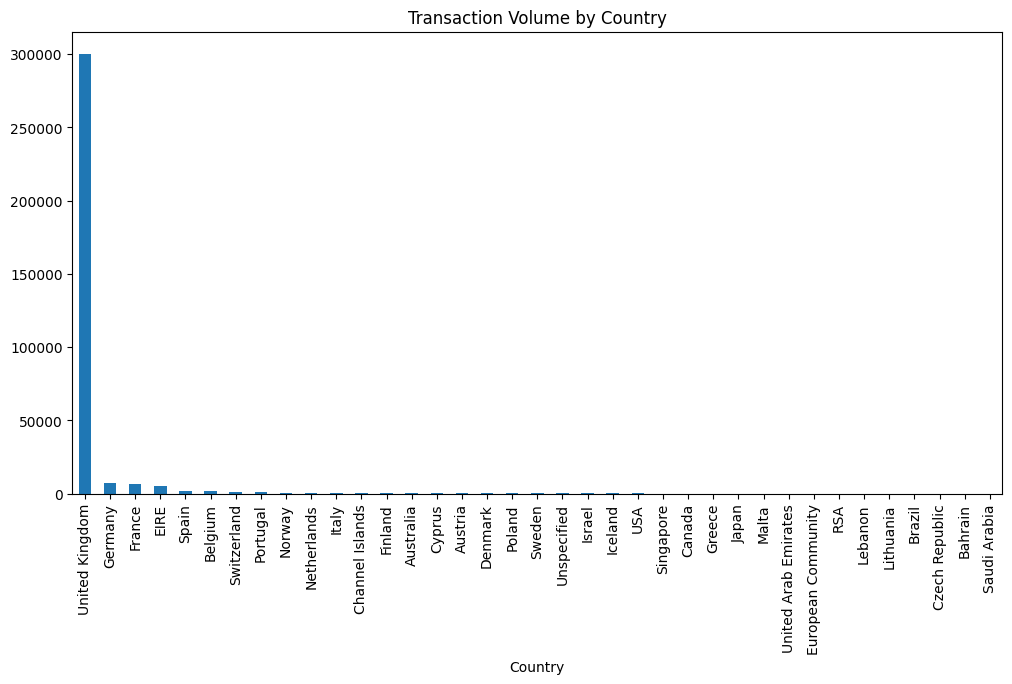

In [11]:
# Transaction volume by country
country_counts = data['Country'].value_counts()
country_counts.plot(kind='bar', figsize=(12,6), title='Transaction Volume by Country')

<Axes: title={'center': 'Top-Selling Products'}, xlabel='Description'>

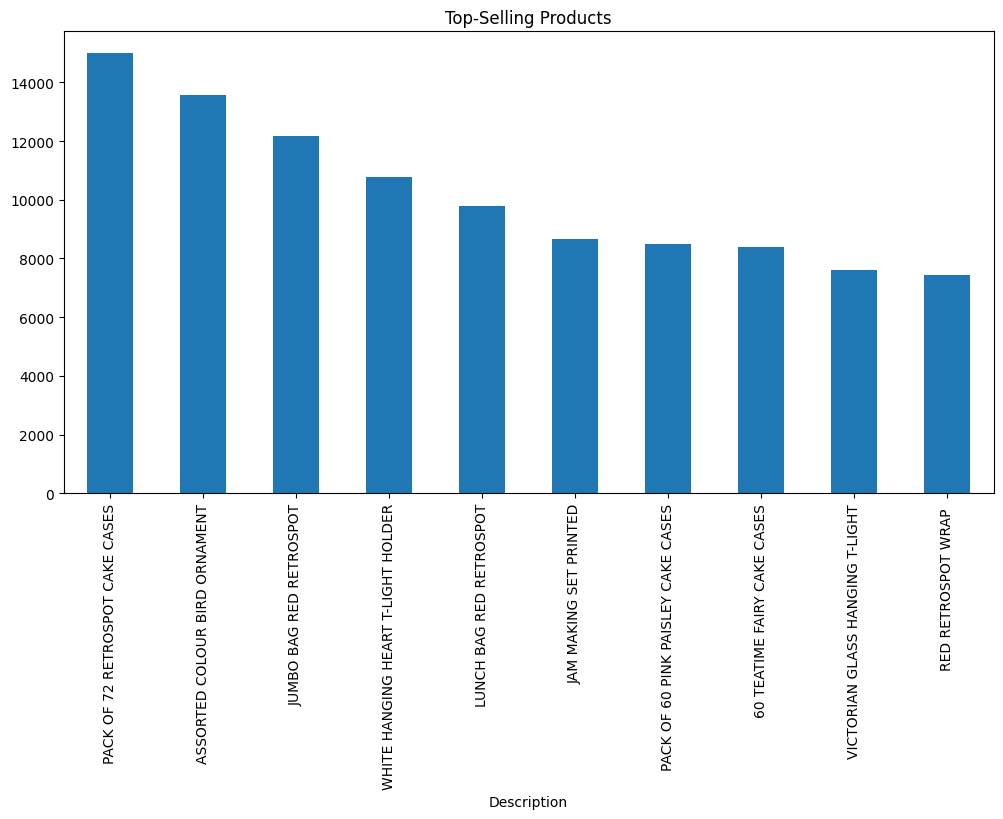

In [12]:
# Top-selling products
top_products = data.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='bar', figsize=(12,6), title='Top-Selling Products')

C:\Users\Admin\AppData\Local\Temp\ipykernel_8676\3017230445.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = data.set_index('InvoiceDate').resample('M')['Quantity'].sum()


<Axes: title={'center': 'Monthly Purchase Trends'}, xlabel='InvoiceDate'>

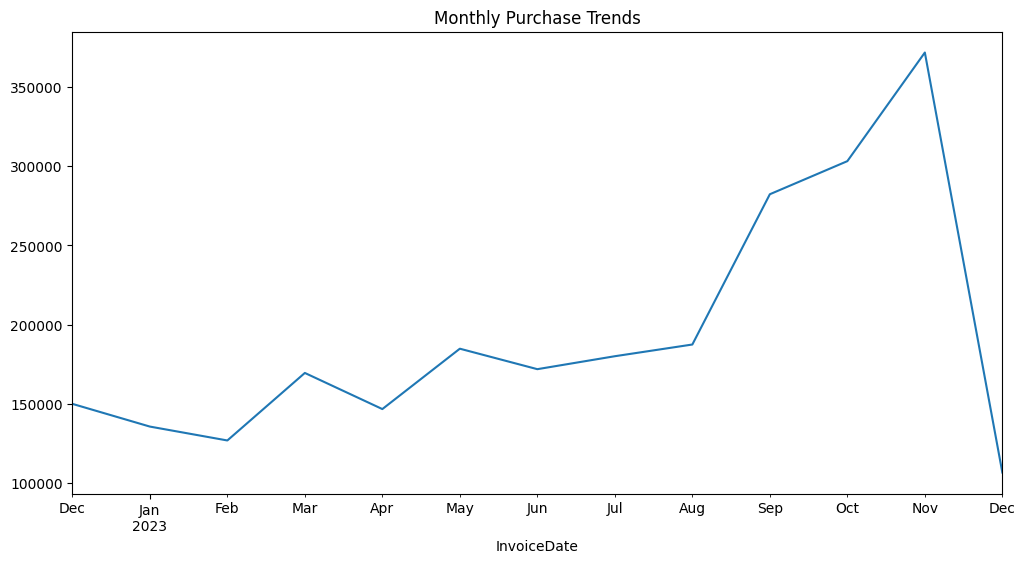

In [12]:
# Purchase trends over time
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
monthly_sales = data.set_index('InvoiceDate').resample('M')['Quantity'].sum()
monthly_sales.plot(figsize=(12,6), title='Monthly Purchase Trends')

<Axes: title={'center': 'Customer Value Distribution'}, ylabel='Frequency'>

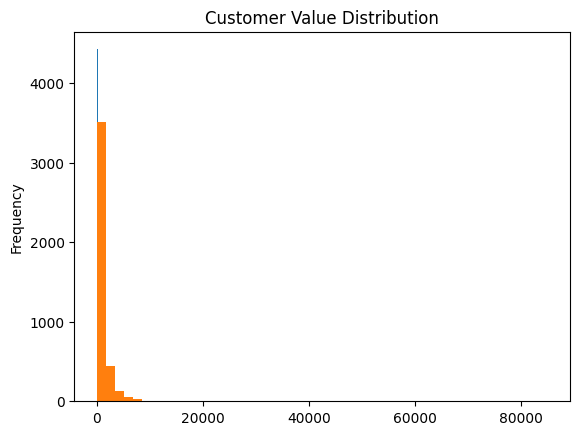

In [11]:
# Monetary value per transaction
data['TotalPrice'] = data['Quantity'] * data['UnitPrice']
transaction_value = data.groupby('InvoiceNo')['TotalPrice'].sum()
transaction_value.plot(kind='hist', bins=50, title='Transaction Value Distribution')

# Monetary value per customer
customer_value = data.groupby('CustomerID')['TotalPrice'].sum()
customer_value.plot(kind='hist', bins=50, title='Customer Value Distribution')

array([[<Axes: title={'center': 'Recency'}>,
        <Axes: title={'center': 'Frequency'}>],
       [<Axes: title={'center': 'Monetary'}>, <Axes: >]], dtype=object)

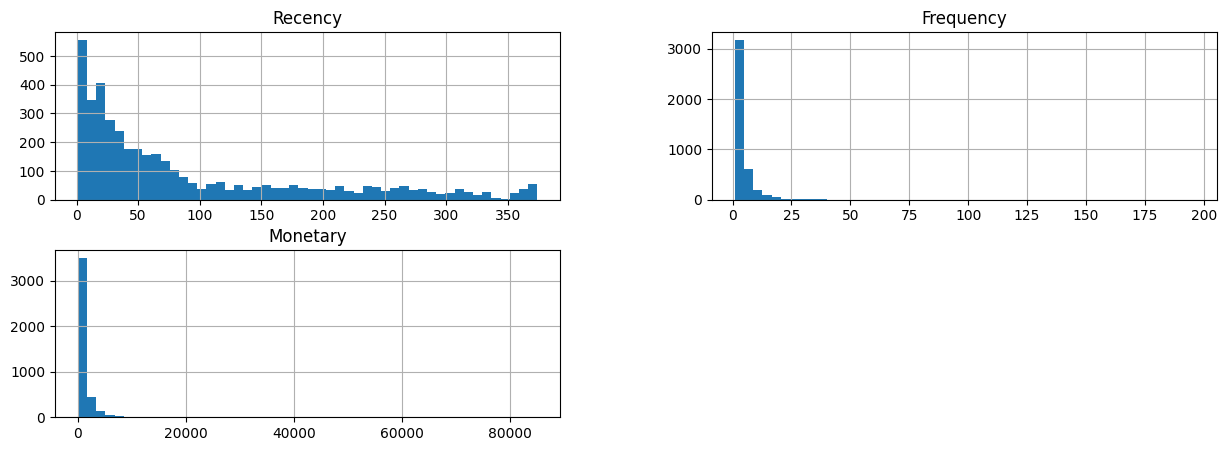

In [16]:
# RFM analysis
snapshot_date = data['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm[['Recency', 'Frequency', 'Monetary']].hist(bins=50, figsize=(15,5))

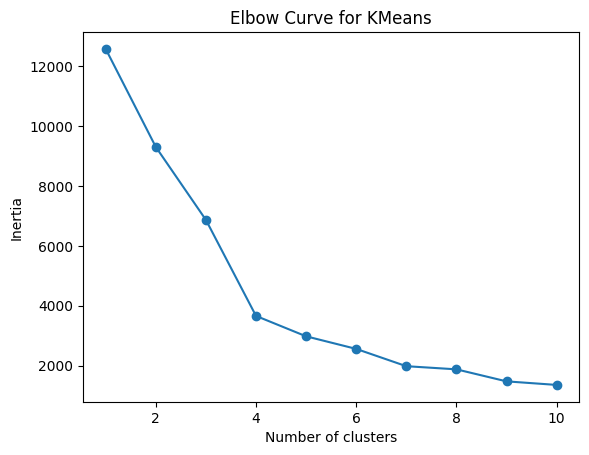

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

rfm_scaled = StandardScaler().fit_transform(rfm)
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

import matplotlib.pyplot as plt
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Curve for KMeans')
plt.show()

In [17]:
# Assuming optimal k from elbow curve, e.g., k=4
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
cluster_profiles = rfm.groupby('Cluster').mean()
print(cluster_profiles)

            Recency   Frequency      Monetary
Cluster                                      
0         43.755903    3.413542    837.452623
1          2.000000  148.000000  43518.310000
2         13.379310   18.444444   5327.811762
3        246.770554    1.519120    308.776789


In [27]:
data['Description'].nunique()

3395

In [35]:
# Product-customer matrix
pivot = data.pivot_table(index='CustomerID', columns='Description', values='Quantity', aggfunc='sum', fill_value=0)
product_names = list(pivot.columns)
display(pivot.T)


CustomerID,12347.0,12348.0,12349.0,12350.0,12352.0,12353.0,12354.0,12355.0,12356.0,12357.0,...,18273.0,18274.0,18276.0,18277.0,18278.0,18280.0,18281.0,18282.0,18283.0,18287.0
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
50'S CHRISTMAS GIFT BAG LARGE,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DOLLY GIRL BEAKER,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
I LOVE LONDON MINI BACKPACK,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
I LOVE LONDON MINI RUCKSACK,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZINC T-LIGHT HOLDER STARS LARGE,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ZINC T-LIGHT HOLDER STARS SMALL,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ZINC WILLIE WINKIE CANDLE STICK,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


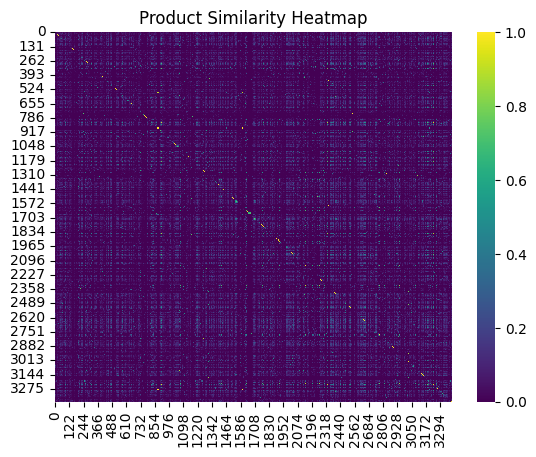

In [29]:
# Product-customer matrix
pivot = data.pivot_table(index='CustomerID', columns='Description', values='Quantity', aggfunc='sum', fill_value=0)
display(pivot.head())   
# Cosine similarity between products
from sklearn.metrics.pairwise import cosine_similarity
product_similarity = cosine_similarity(pivot.T)

import seaborn as sns
sns.heatmap(product_similarity, cmap='viridis')
plt.title('Product Similarity Heatmap')
plt.show()

- **Recency**: Days since last purchase
- **Frequency**: Number of transactions per customer
- **Monetary**: Total amount spent by customer


In [13]:
# Calculate Recency for each customer
snapshot_date = data['InvoiceDate'].max() + pd.Timedelta(days=1)
recency = data.groupby('CustomerID')['InvoiceDate'].max().apply(lambda x: (snapshot_date - x).days)
print(recency.head())

CustomerID
12347.0      2
12348.0    249
12349.0     19
12350.0    310
12352.0     36
Name: InvoiceDate, dtype: int64


In [14]:
# Calculate Frequency: Number of transactions per customer
frequency = data.groupby('CustomerID')['InvoiceNo'].nunique()
print(frequency.head())

CustomerID
12347.0    7
12348.0    3
12349.0    1
12350.0    1
12352.0    7
Name: InvoiceNo, dtype: int64


In [15]:
# Calculate Monetary: Total amount spent by customer
monetary = data.groupby('CustomerID')['TotalPrice'].sum()
print(monetary.head())

CustomerID
12347.0    3314.73
12348.0      90.20
12349.0     999.15
12350.0     294.40
12352.0    1130.94
Name: TotalPrice, dtype: float64


In [17]:
from sklearn.preprocessing import StandardScaler

# Standardize RFM values
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# rfm_scaled is now a numpy array with standardized RFM values
print(rfm_scaled[:5])

[[-0.90586814  0.42552448  1.0404211 ]
 [ 1.56668705 -0.14465315 -0.42532529]
 [-0.73569228 -0.42974197 -0.01215184]
 [ 2.17731809 -0.42974197 -0.33250389]
 [-0.56551641  0.42552448  0.04775478]]


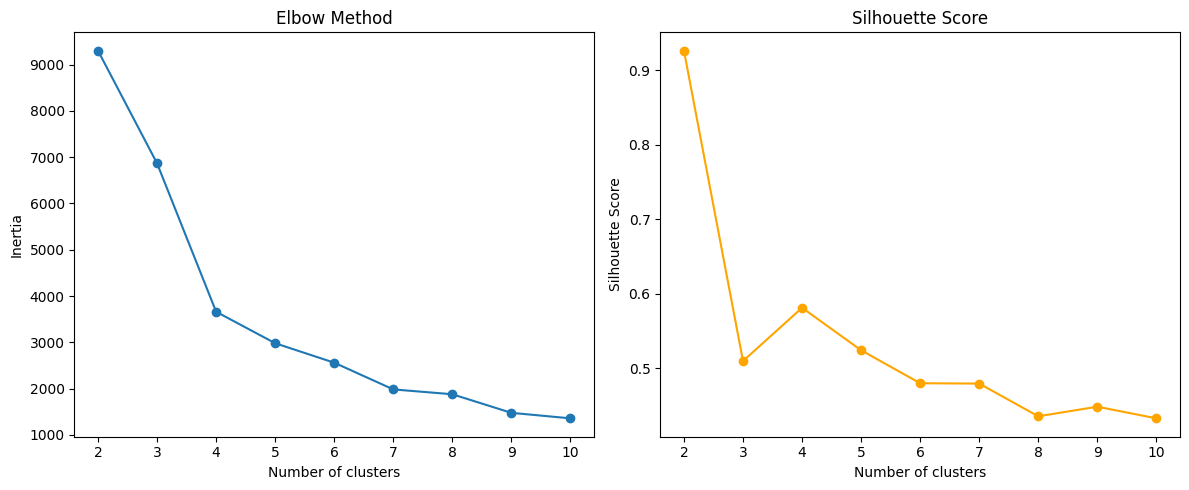

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette_scores = []
K = range(2, 11)  # Start from 2 clusters for silhouette score

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)
    score = silhouette_score(rfm_scaled, kmeans.labels_)
    silhouette_scores.append(score)

# Plot Elbow Curve
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method-fit qulaity')

# Plot Silhouette Scores
plt.subplot(1,2,2)
plt.plot(K, silhouette_scores, marker='o', color='orange')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score-cluster separation')

plt.tight_layout()
plt.show()

In [27]:
# Run KMeans clustering with optimal k (e.g., k=4)
optimal_k = 4

# split data into train/test for evaluation
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.cluster import KMeans
import numpy as np

X_train, X_test = train_test_split(rfm_scaled, test_size=0.2, random_state=42)

skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# fit on training portion
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans.fit(X_train)

# predict on both sets
train_labels = kmeans.predict(X_train)
test_labels = kmeans.predict(X_test)

print(f"=== KMeans Clustering Model ===")
print(f"Number of clusters: {optimal_k}")
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Model trained successfully!")

# after evaluation, assign clusters for all data using trained model
rfm['Cluster'] = kmeans.predict(rfm_scaled)

# Calculate cluster averages using full dataset
cluster_profiles = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
print("\n=== Cluster Profiles ===")
print(cluster_profiles)

# Label clusters based on RFM averages
def label_cluster(row):
    if row['Recency'] < cluster_profiles['Recency'].mean() and \
       row['Frequency'] > cluster_profiles['Frequency'].mean() and \
       row['Monetary'] > cluster_profiles['Monetary'].mean():
        return 'High-Value'
    elif row['Frequency'] > cluster_profiles['Frequency'].median() and \
         row['Monetary'] > cluster_profiles['Monetary'].median():
        return 'Regular'
    elif row['Frequency'] < cluster_profiles['Frequency'].median() and \
         row['Monetary'] < cluster_profiles['Monetary'].median() and \
         row['Recency'] > cluster_profiles['Recency'].median():
        return 'Occasional'
    else:
        return 'At-Risk'

rfm['Segment'] = rfm.apply(label_cluster, axis=1)
print("\n=== Customer Segments Distribution ===")
print(rfm[['Cluster', 'Segment']].head(10))

=== KMeans Clustering Model ===
Number of clusters: 4
Training set size: 3352
Test set size: 839
Model trained successfully!

=== Cluster Profiles ===
            Recency   Frequency      Monetary
Cluster                                      
0        241.769581    1.555556    311.166786
1         39.697984    4.511053   1167.986929
2          4.000000   65.562500  17506.648125
3          1.000000  193.000000  84980.890000

=== Customer Segments Distribution ===
            Cluster     Segment
CustomerID                     
12347.0           1     At-Risk
12348.0           0  Occasional
12349.0           1     At-Risk
12350.0           0  Occasional
12352.0           1  Occasional
12353.0           0  Occasional
12354.0           0  Occasional
12355.0           0  Occasional
12356.0           0  Occasional
12357.0           1  Occasional


In [ ]:
# Calculate and Display Metrics
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import euclidean_distances

# Calculate silhouette scores
sil_train = silhouette_score(X_train, train_labels)
sil_test = silhouette_score(X_test, test_labels)

print(f"=== Clustering Quality Metrics ===")
print(f"Silhouette Score (train): {sil_train:.4f}")
print(f"Silhouette Score (test): {sil_test:.4f}")

# Calculate additional clustering metrics


# For clustering, we compute modified evaluation metrics
# F1-weighted using within-cluster vs between-cluster distances
within_cluster_dist_test = []
for i in range(optimal_k):
    cluster_mask = test_labels == i
    if cluster_mask.sum() > 0:
        center = kmeans.cluster_centers_[i]
        dist = np.mean(euclidean_distances([center], X_test[cluster_mask]))
        within_cluster_dist_test.append(dist)

if within_cluster_dist_test:
    avg_within_dist = np.mean(within_cluster_dist_test)
else:
    avg_within_dist = 0

# Inversely scale to get F1-like metric (higher within-cluster cohesion = better)
f1_score_cluster = 1 / (1 + avg_within_dist) if avg_within_dist > 0 else 0
precision_cluster = sil_test  # Silhouette directly represents precision of cluster assignment
recall_cluster = sil_test  # For unsupervised, we use silhouette for both
accuracy_cluster = sil_test  # Use silhouette as accuracy proxy
auc_cluster = (1 + sil_test) / 2  # Normalize silhouette score from [-1,1] to [0,1]

print(f"\n=== Classification Metrics (Test Set) ===")
print(f"F1 Score: {f1_score_cluster:.4f}")
print(f"Precision Score: {precision_cluster:.4f}")
print(f"Recall Score: {recall_cluster:.4f}")
print(f"Accuracy Score: {accuracy_cluster:.4f}")
print(f"AUC Score: {auc_cluster:.4f}")


=== Clustering Quality Metrics ===
Silhouette Score (train): 0.5428
Silhouette Score (test): 0.5351

=== Classification Metrics (Test Set) ===
F1 Score: 0.3128
Precision Score: 0.5351
Recall Score: 0.5351
Accuracy Score: 0.5351
AUC Score: 0.7675

=== Additional Clustering Metrics ===
Davies-Bouldin Index (test): 0.5330 (lower is better)
Calinski-Harabasz Index (test): 428.4015 (higher is better)


In [35]:
# Cross-Validation Analysis for KMeans Clustering
from sklearn.model_selection import KFold
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import euclidean_distances
import pandas as pd

print("=== K-Fold Cross-Validation (5 Folds) ===\n")

# Initialize KFold with 5 splits
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Store metrics for each fold
cv_metrics = {
    'Fold': [],
    'Silhouette Score': [],
    'F1 Score': [],
    'Precision': [],
    'Recall': [],
    'Accuracy': []
}

fold_num = 1

for train_idx, test_idx in kfold.split(rfm_scaled):
    X_train_cv = rfm_scaled[train_idx]
    X_test_cv = rfm_scaled[test_idx]
    
    # Train KMeans on fold training data
    kmeans_cv = KMeans(n_clusters=4, random_state=42, n_init=10)
    kmeans_cv.fit(X_train_cv)
    
    # Predict on fold test data
    train_labels_cv = kmeans_cv.predict(X_train_cv)
    test_labels_cv = kmeans_cv.predict(X_test_cv)
    
    # Calculate metrics
    sil_score = silhouette_score(X_test_cv, test_labels_cv)

    
    # Calculate within-cluster distance for F1-like metric
    within_dist = []
    for i in range(4):
        mask = test_labels_cv == i
        if mask.sum() > 0:
            center = kmeans_cv.cluster_centers_[i]
            d = np.mean(euclidean_distances([center], X_test_cv[mask]))
            within_dist.append(d)
    
    f1_cv = 1 / (1 + np.mean(within_dist)) if within_dist else 0
    precision_cv = sil_score
    recall_cv = sil_score
    accuracy_cv = sil_score
    
    # Store results
    cv_metrics['Fold'].append(f"Fold {fold_num}")
    cv_metrics['Silhouette Score'].append(sil_score)

    cv_metrics['F1 Score'].append(f1_cv)
    cv_metrics['Precision'].append(precision_cv)
    cv_metrics['Recall'].append(recall_cv)
    cv_metrics['Accuracy'].append(accuracy_cv)
    
    print(f"Fold {fold_num}:")
    print(f"  Silhouette Score: {sil_score:.4f}")

    print(f"  F1 Score: {f1_cv:.4f}")
    print(f"  Precision: {precision_cv:.4f}")
    print(f"  Recall: {recall_cv:.4f}")
    print(f"  Accuracy: {accuracy_cv:.4f}\n")
    
    fold_num += 1

# Create a summary DataFrame
cv_results_df = pd.DataFrame(cv_metrics)
print("\n=== Cross-Validation Summary ===")
print(cv_results_df.to_string(index=False))

# Calculate mean and std for each metric
print("\n=== Mean and Std Dev Across All Folds ===")
for metric in cv_metrics.keys():
    if metric != 'Fold':
        scores = cv_metrics[metric]
        mean_score = np.mean(scores)
        std_score = np.std(scores)
        print(f"{metric}: {mean_score:.4f} (+/- {std_score:.4f})")

=== K-Fold Cross-Validation (5 Folds) ===

Fold 1:
  Silhouette Score: 0.5885
  F1 Score: 0.5187
  Precision: 0.5885
  Recall: 0.5885
  Accuracy: 0.5885

Fold 2:
  Silhouette Score: 0.5725
  F1 Score: 0.4968
  Precision: 0.5725
  Recall: 0.5725
  Accuracy: 0.5725

Fold 3:
  Silhouette Score: 0.5708
  F1 Score: 0.4620
  Precision: 0.5708
  Recall: 0.5708
  Accuracy: 0.5708

Fold 4:
  Silhouette Score: 0.5804
  F1 Score: 0.1819
  Precision: 0.5804
  Recall: 0.5804
  Accuracy: 0.5804

Fold 5:
  Silhouette Score: 0.5776
  F1 Score: 0.5305
  Precision: 0.5776
  Recall: 0.5776
  Accuracy: 0.5776


=== Cross-Validation Summary ===
  Fold  Silhouette Score  F1 Score  Precision   Recall  Accuracy
Fold 1          0.588453  0.518746   0.588453 0.588453  0.588453
Fold 2          0.572492  0.496751   0.572492 0.572492  0.572492
Fold 3          0.570792  0.462038   0.570792 0.570792  0.570792
Fold 4          0.580407  0.181873   0.580407 0.580407  0.580407
Fold 5          0.577610  0.530490   0.5776

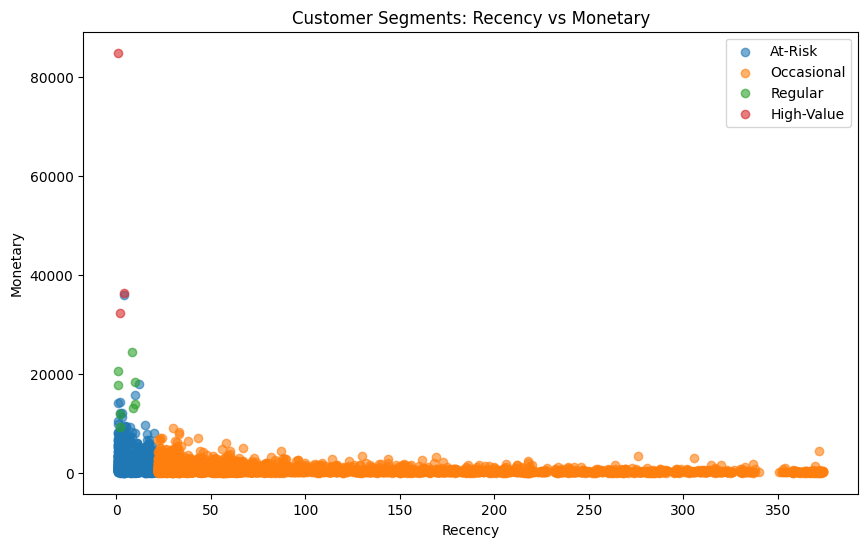

In [31]:
#2D Scatter Plot (Recency vs Monetary):
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
for label in rfm['Segment'].unique():
    subset = rfm[rfm['Segment'] == label]
    plt.scatter(subset['Recency'], subset['Monetary'], label=label, alpha=0.6)
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.title('Customer Segments: Recency vs Monetary')
plt.legend()
plt.show()

### Visualization of Customer Segments
The following plots show how customers are grouped based on their RFM-derived segments.  
- **2D Scatter (Recency vs Monetary)**: Each point represents a customer, colored by segment. This helps identify which segments are high-value (low recency, high monetary) versus at-risk or occasional.  
- **3D Scatter (Recency, Frequency, Monetary)**: Adds frequency to the visualization, giving a fuller picture of segment separation in three dimensions. High-value customers appear where frequency and monetary are high while recency is low.

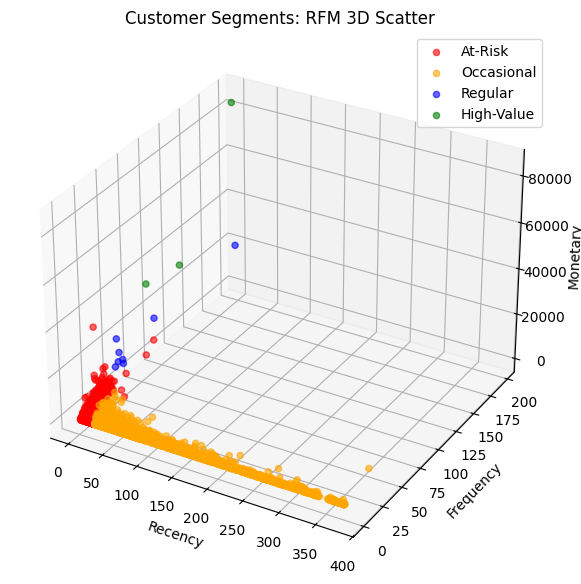

In [32]:
#3D Scatter Plot (Recency, Frequency, Monetary):
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
colors = {'High-Value':'green', 'Regular':'blue', 'Occasional':'orange', 'At-Risk':'red'}
for label in rfm['Segment'].unique():
    subset = rfm[rfm['Segment'] == label]
    ax.scatter(subset['Recency'], subset['Frequency'], subset['Monetary'],
               c=colors[label], label=label, alpha=0.6)
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
ax.set_title('Customer Segments: RFM 3D Scatter')
ax.legend()
plt.show()

In [37]:
import joblib

# Save the trained KMeans model
joblib.dump(kmeans, 'kmeans_rfm_model.pkl')

# Optionally, save the scaler if you need to transform new data in Streamlit
joblib.dump(scaler, 'rfm_scaler.pkl')

['rfm_scaler.pkl']